# >> Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# >> Loading & Inspecting the Dataset


In [ ]:
df = pd.read_excel("/content/Obesity_Level_Estimation_Dataset.xlsx")
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


# >> Exploratory Data Analysis (EDA)


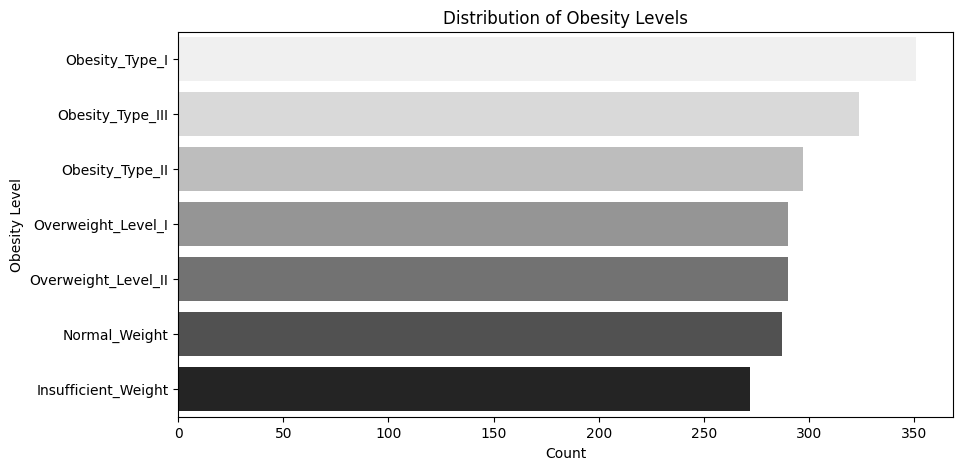

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='NObeyesdad', data=df, order=df['NObeyesdad'].value_counts().index, palette='Greys')
plt.title("Distribution of Obesity Levels")
plt.xlabel("Count")
plt.ylabel("Obesity Level")
plt.show()

In [ ]:
df['NObeyesdad'].value_counts()

,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


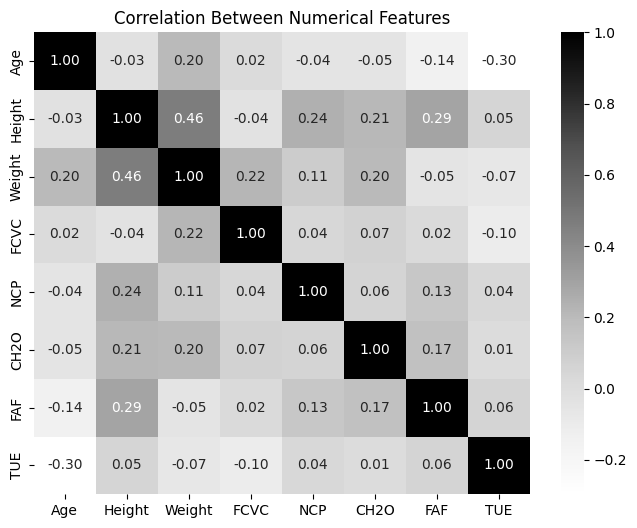

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='Greys', fmt='.2f')
plt.title("Correlation Between Numerical Features")
plt.show()

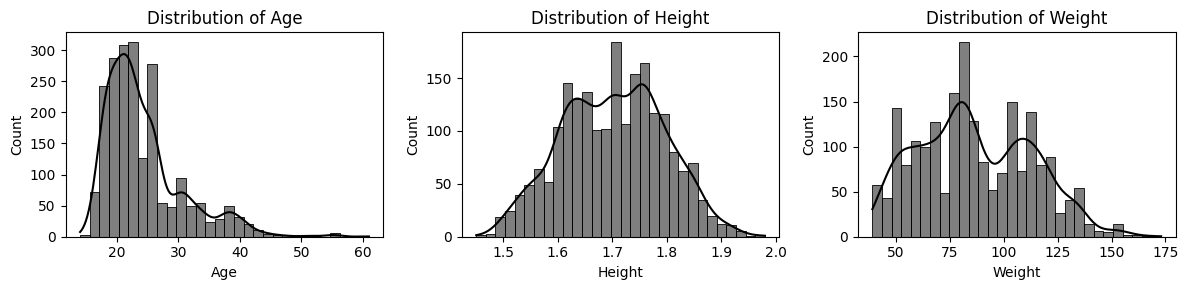

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, col in enumerate(['Age', 'Height', 'Weight']):
    sns.histplot(df[col], kde=True, bins=30, color='black', ax=axes[i]).set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

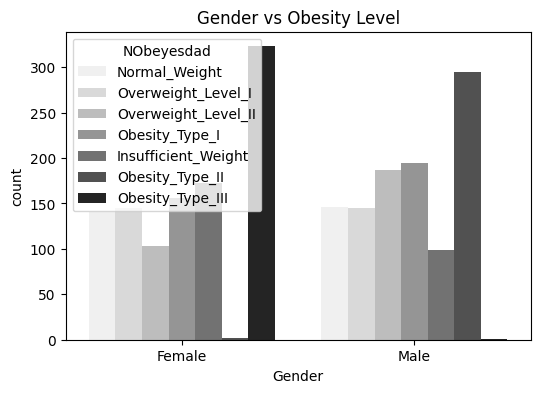

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='NObeyesdad', data=df, palette='Greys')
plt.title("Gender vs Obesity Level")
plt.show()

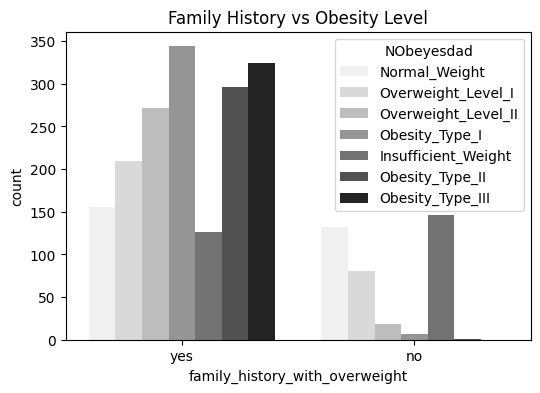

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='family_history_with_overweight', hue='NObeyesdad', data=df, palette='Greys')
plt.title("Family History vs Obesity Level")
plt.show()

# >> Data Preprocessing


In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS', 'NObeyesdad']
Numerical Columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [ ]:
label_encoders = {}
for col in cat_cols:
    if col != 'NObeyesdad':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [ ]:
target_encoder = LabelEncoder()
df['NObeyesdad'] = target_encoder.fit_transform(df['NObeyesdad'])

In [ ]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

In [ ]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")
print(f"Feature count: {X_train.shape[1]}")

Training samples: 1688, Testing samples: 423
Feature count: 16


# **OBJECTIVE 1 > MULTI-CLASS OBESITY LEVEL CLASSIFICATION**


## Algorithm 1 >> Support Vector Machine (SVM)


In [ ]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

SVC(C=10, probability=True, random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")

SVM Accuracy: 0.9574


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=target_encoder.classes_))

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.98      0.97        54
      Normal_Weight       0.90      0.91      0.91        58
     Obesity_Type_I       0.93      0.99      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.95      0.91      0.93        58
Overweight_Level_II       0.98      0.93      0.96        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



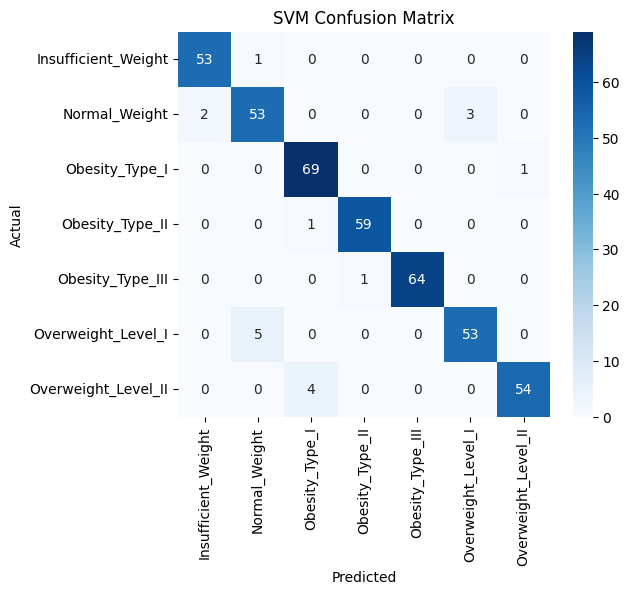

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Algorithm 2 >> Random Forest (RF)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Random Forest Accuracy: 0.9574


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=target_encoder.classes_))

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.84      0.98      0.90        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.90      0.93        58
Overweight_Level_II       0.96      0.95      0.96        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



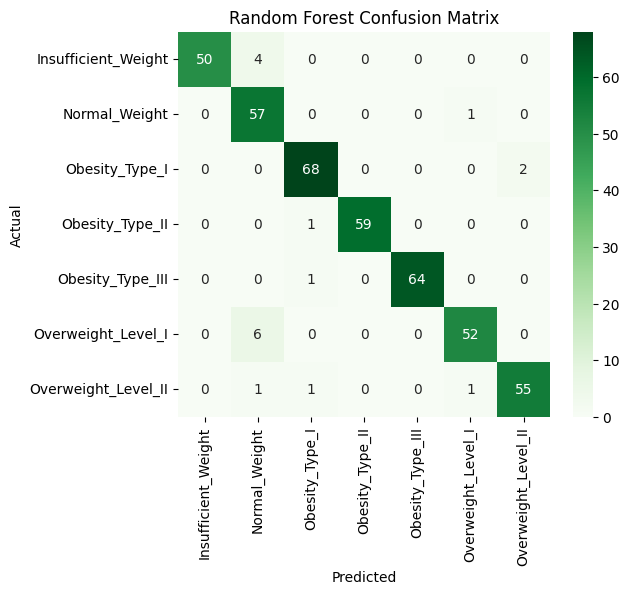

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Algorithm 3 >> XGBoost


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softmax',
    num_class=len(target_encoder.classes_),
    eval_metric='mlogloss',
    random_state=42
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None, num_class=7, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.4f}")

XGBoost Accuracy: 0.9622


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.85      0.98      0.91        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.91      0.95        58
Overweight_Level_II       0.97      0.98      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.97      0.96      0.96       423



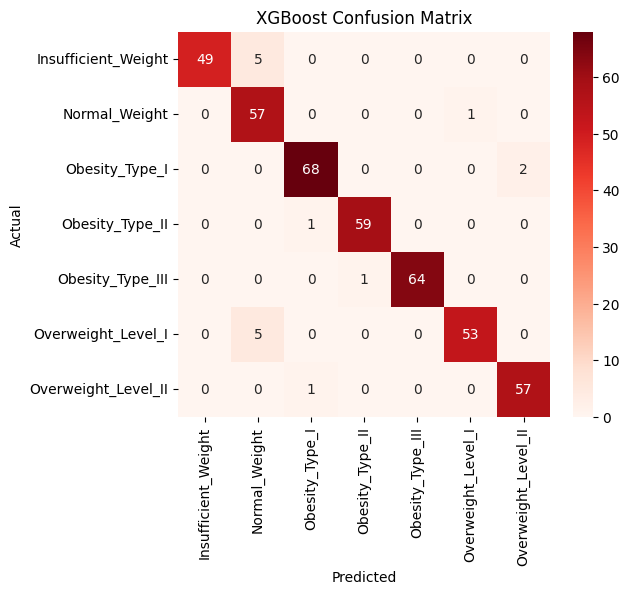

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

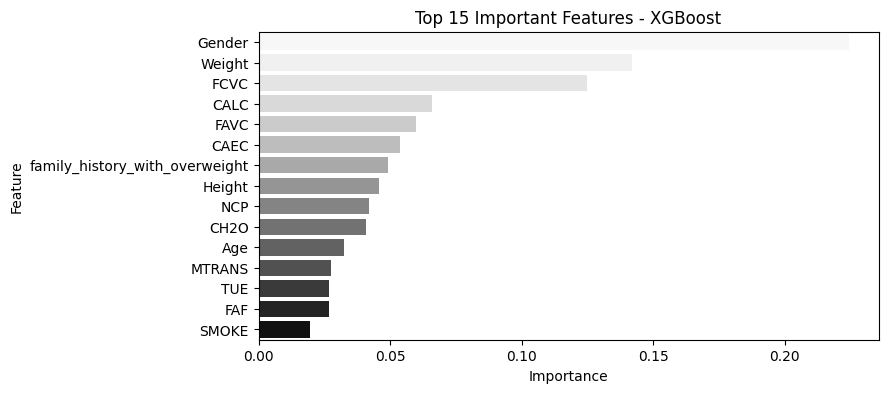

In [ ]:
importance_xgb = xgb_model.feature_importances_
feat_imp_xgb = pd.DataFrame({'Feature': X_train.columns,'Importance': importance_xgb}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=feat_imp_xgb.head(15), palette='Greys')
plt.title("Top 15 Important Features - XGBoost")
plt.show()

## Algorithm 4 >> Blended Ensemble (SVM + RF + XGBoost)


In [ ]:
svm_probs = svm_model.predict_proba(X_test)
rf_probs = rf_model.predict_proba(X_test)
xgb_probs = xgb_model.predict_proba(X_test)

In [ ]:
blend_probs = (0.2 * svm_probs) + (0.3 * rf_probs) + (0.5 * xgb_probs)

In [ ]:
y_pred_blend = np.argmax(blend_probs, axis=1)

In [ ]:
acc_blend = accuracy_score(y_test, y_pred_blend)
print(f"Blended Model Accuracy: {acc_blend:.4f}")

Blended Model Accuracy: 0.9598


In [ ]:
print("Classification Report (Blended Model):")
print(classification_report(y_test, y_pred_blend, target_names=target_encoder.classes_))

Classification Report (Blended Model):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.89      0.94        54
      Normal_Weight       0.84      0.98      0.90        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.91      0.95        58
Overweight_Level_II       0.97      0.98      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



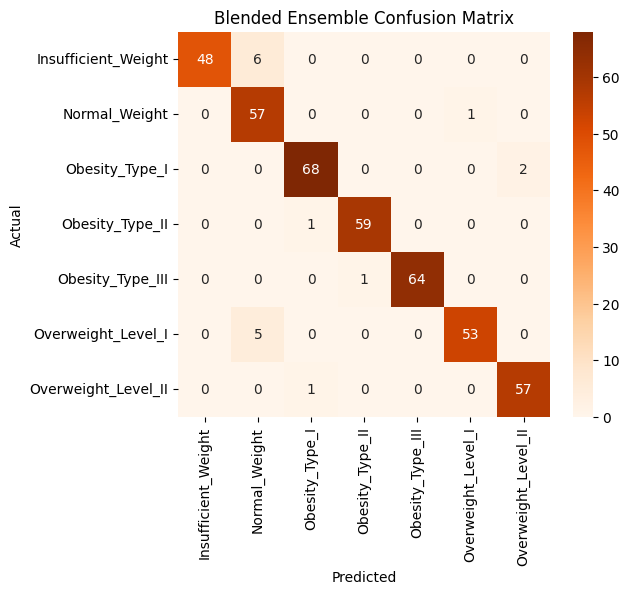

In [ ]:
cm_blend = confusion_matrix(y_test, y_pred_blend)
plt.figure(figsize=(6,5))
sns.heatmap(cm_blend, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("Blended Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## >> Model Accuracy Comparison

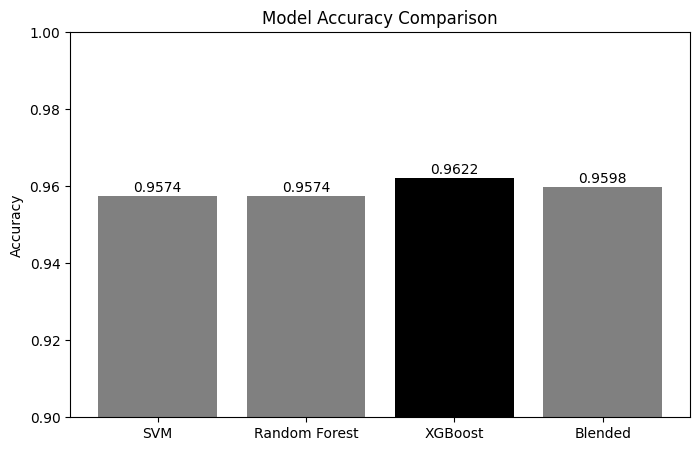

In [ ]:
models = ['SVM', 'Random Forest', 'XGBoost', 'Blended']
accuracies = [acc_svm, acc_rf, acc_xgb, acc_blend]
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['grey','grey','black','grey'])
plt.ylim(0.90,1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')
plt.show()

# **OBJECTIVE 2 > FEATURE SELECTION VS MODEL COMPLEXITY TRADE-OFFS**


## >> Most Important Feature Selection Table - XGBoost


In [ ]:
feat_imp_xgb = pd.DataFrame({'Feature': X_train.columns,'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)
print("Feature Ranking Based on XGBoost Importance:\n")
print(feat_imp_xgb)

Feature Ranking Based on XGBoost Importance:

                           Feature  Importance
1                           Gender    0.224452
3                           Weight    0.141923
6                             FCVC    0.125022
4                             CALC    0.066091
5                             FAVC    0.059682
14                            CAEC    0.053615
11  family_history_with_overweight    0.049072
2                           Height    0.045932
7                              NCP    0.041834
10                            CH2O    0.040750
0                              Age    0.032452
15                          MTRANS    0.027403
13                             TUE    0.026806
12                             FAF    0.026760
9                            SMOKE    0.019668
8                              SCC    0.018539


## >> Model Complexity Trade-Off : Effect of Feature Reduction on Accuracy


In [ ]:
feature_ranks = feat_imp_xgb['Feature'].tolist()
subset_sizes = [3, 5, 8, 10, len(feature_ranks)]
subset_names = ["Top 3", "Top 5", "Top 8", "Top 10", "All 16"]
subset_accuracies = []
print("Testing XGBoost With Different Feature Subsets:\n")
for size in subset_sizes:
    selected_features = feature_ranks[:size]

    X_train_sub = X_train[selected_features]
    X_test_sub = X_test[selected_features]

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(target_encoder.classes_),
        eval_metric='mlogloss',
        random_state=42
    )
    model.fit(X_train_sub, y_train)
    preds = model.predict(X_test_sub)
    acc = accuracy_score(y_test, preds)
    subset_accuracies.append(acc)
    print(f"{size} features ({subset_names[subset_sizes.index(size)]}): Accuracy = {acc:.4f}")

Testing XGBoost With Different Feature Subsets:

3 features (Top 3): Accuracy = 0.8132
5 features (Top 5): Accuracy = 0.8416
8 features (Top 8): Accuracy = 0.9527
10 features (Top 10): Accuracy = 0.9574
16 features (All 16): Accuracy = 0.9551


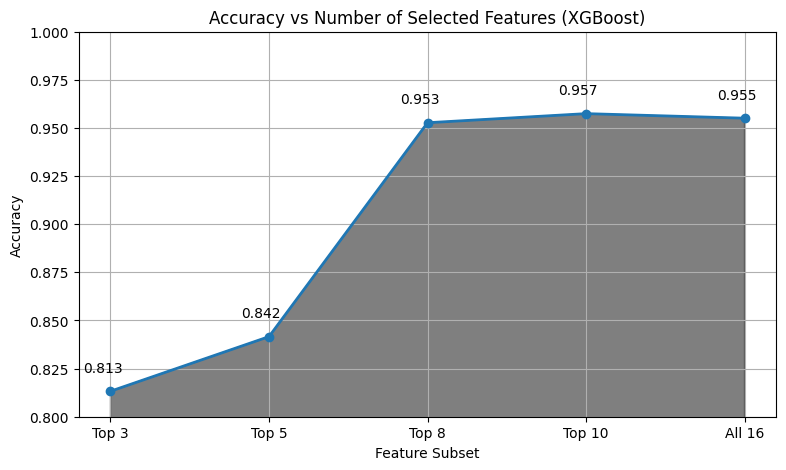

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(subset_names, subset_accuracies, marker='o', linestyle='-', linewidth=2)
plt.fill_between(subset_names, subset_accuracies, color='black', alpha=0.5)
plt.ylim(0.8,1)
plt.title("Accuracy vs Number of Selected Features (XGBoost)")
plt.xlabel("Feature Subset")
plt.ylabel("Accuracy")
for i, v in enumerate(subset_accuracies):
    plt.text(i-0.05, v+0.01, f"{v:.3f}", ha='center')
plt.grid(True)
plt.show()

## >> Performance Comparison Table - All Models & Feature Subsets


| Models                             | Features Used | Accuracy      | Notes                                            |
| --------------------------------- | ------------- | ------------- | ------------------------------------------------ |
| **> SVM (RBF)**                     | All 16        | 0.9574        | Strong baseline, performs well with scaling      |
| **> Random Forest**                 | All 16        | 0.9574        | Good interpretability via feature importance     |
| **>> XGBoost**                       | All 16        | **0.9622**    | Best overall performer                           |
| **> Blended Ensemble (SVM+RF+XGB)** | All 16        | 0.9598        | Slightly below XGBoost - blending didn’t improve |

| Top Feature Subsets - XGBoost             | Features Used | Accuracy      | Notes                                            |
| --------------------------------- | ------------- | ------------- | ------------------------------------------------ |
| **> Top 3 Features - XGBoost** | Top 3         | 0.8132        | Insufficient features - poor accuracy            |
| **> Top 5 Features - XGBoost**               | Top 5         | 0.8416        | Still low - model too simplistic                 |
| **> Top 8 Features - XGBoost**               | Top 8         | 0.9527        | Very close to full accuracy - ideal trade-off    |
| **> Top 10 Features - XGBoost**              | Top 10        | 0.9574        | Nearly best - diminishing returns begin          |
| **> Top 16 Features - XGBoost**              | All features  | 0.9551        | Slightly below best due to weaker features noise |
